# CS 4379G Assignment_01
## Assignment Goals: Answer the following questions: </br>How has the number of titles added to Netflix changed over time (by year)?</br>Which countries (or genres/listed_in categories) contribute the most titles, and how has that changed over time? 

### Imports and Settings

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')

### Data loading and a brief data dictionary (what each key column means).

In [47]:
# load data
df = pd.read_csv("../data/netflix_titles.csv")

# data dictionary of each key column
df.columns.tolist()

['show_id',
 'type',
 'title',
 'director',
 'cast',
 'country',
 'date_added',
 'release_year',
 'rating',
 'duration',
 'listed_in',
 'description']

## Data cleaning

In [48]:
# check for missing values
df.isna().sum().sort_values(ascending=False).head(12)

# drop duplicates
df_unique = df.drop_duplicates()

# Parse dates (coerce errors -> NaT)
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")
df["year_added"] = df["date_added"].dt.year


In [49]:
# count by function
def count_by(column_name: str, drop: bool):
    column_counts = df[column_name].value_counts(dropna=drop)
    print(column_counts)
    return column_counts

## **Analysis**
### Grouped summary: counts or summary stats by a categorical feature (e.g., type, rating, country, listed in).
### Titles counted by type (Movies vs. Shows) and titles counted by country

In [50]:
# Title count by type
type_counts = count_by("type", False)


type
Movie      6131
TV Show    2676
Name: count, dtype: int64


In [61]:
# Title count by country (Not including NaN)
country_counts = count_by("country", True)
country_counts.head()

country
United States                                    2818
India                                             972
United Kingdom                                    419
Japan                                             245
South Korea                                       199
                                                 ... 
Russia, Spain                                       1
Croatia, Slovenia, Serbia, Montenegro               1
Japan, Canada                                       1
United States, France, South Korea, Indonesia       1
United Arab Emirates, Jordan                        1
Name: count, Length: 748, dtype: int64


country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Name: count, dtype: int64

### Trend over time: titles per year (e.g., using release year or parsing date added).
### Titles per release year

In [52]:
# Titles added per year (ignoring missing dates)
added_per_year = df.dropna(subset=["year_added"]).groupby("year_added").size()
#added_per_year.tail()
print(added_per_year)


year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     418
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
dtype: int64


In [99]:
# Titles added per year by country
per_year_by_country = df.groupby(['year_added', 'country']).size().unstack(fill_value=0)

## **Visualization**
### One distribution plot (e.g., histogram/boxplot of cleaned duration or release year; or bar chart of ratings).
### One relationship plot (e.g., line chart of titles per year; grouped bar chart comparing Movies vs TV Shows by rating; scatter/strip plot if appropriate).
### Each plot must have:
### • A title.
### • Labeled axes (when applicable).
### • A 2–4 sentence interpretation below the plot (what does it show?).

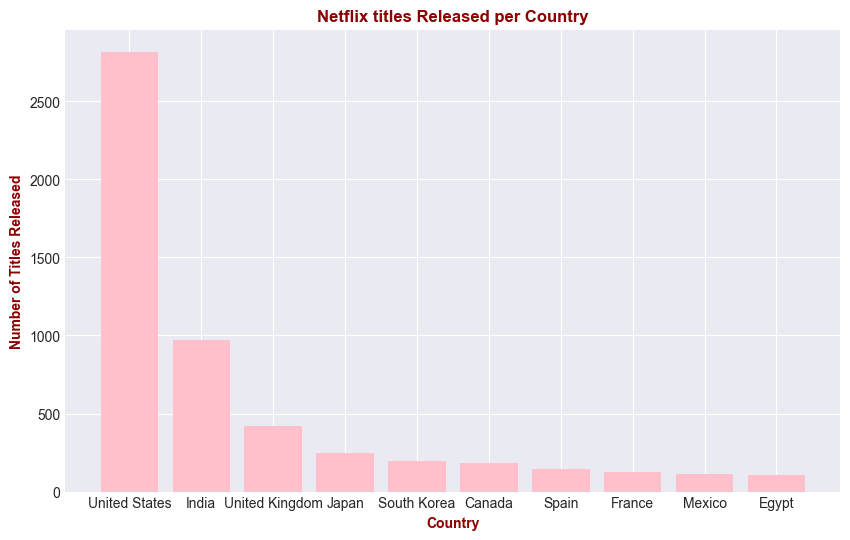

In [92]:
# Bar chart of titles per country
plt.figure(figsize=(10, 6))
plt.bar(country_counts.head(10).index.astype(str), country_counts.head(10).values, color = 'pink')

plt.xlabel("Country", fontweight='bold', color='darkred')
plt.ylabel("Number of Titles Released", fontweight='bold', color='darkred')
plt.title("Netflix titles Released per Country", fontweight='bold', color='darkred')
plt.show()

This chart shows that the United States leads the number of titles released per country, closely followed by India.

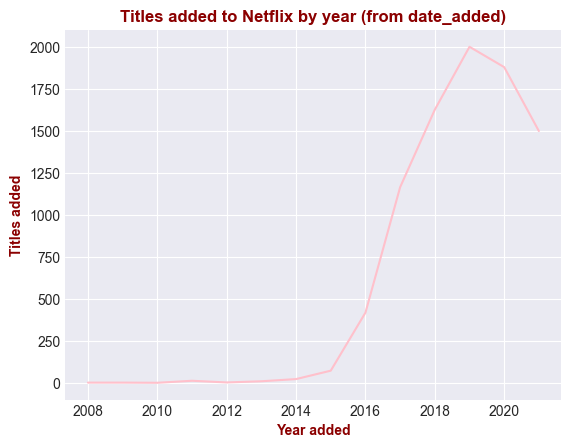

In [54]:
# Line chart of titles added to Netflix by year
plt.figure()
plt.plot(added_per_year.index, added_per_year.values, color='pink')
plt.xlabel("Year added", fontweight='bold', color='darkred')
plt.ylabel("Titles added", fontweight='bold', color='darkred')
plt.title("Titles added to Netflix by year (from date_added)", fontweight='bold', color='darkred')
plt.show()

This line chart shows a spike in Titles added to Netflix in 2018-2019. This peak may suggest a year of higher streaming rates.

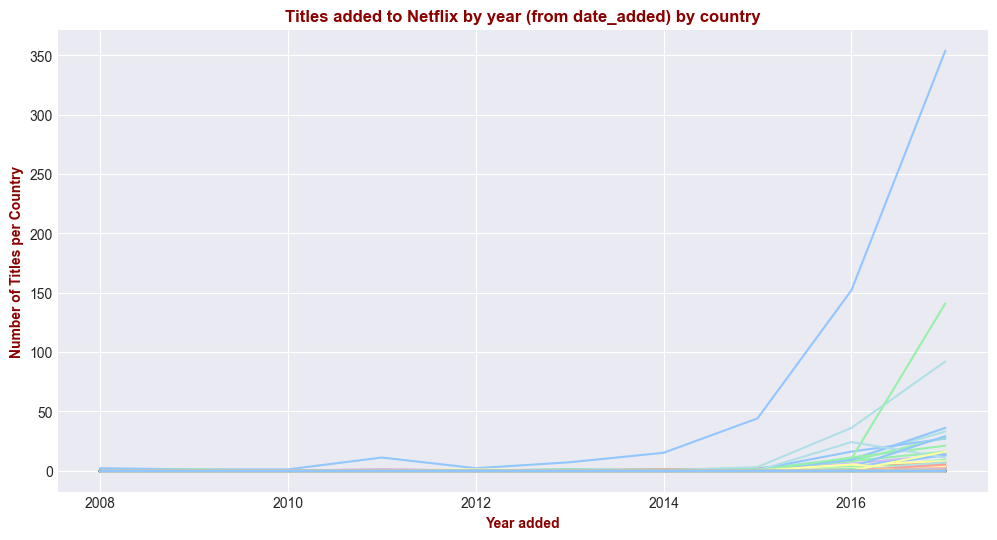

In [100]:
# Bar Chart of titles added to Netflix by year, by country
plt.figure(figsize=(12,6))
plt.plot(per_year_by_country.head(10).index.astype(int), per_year_by_country.head(10).values)
plt.xlabel("Year added", fontweight='bold', color='darkred')
plt.ylabel("Number of Titles per Country", fontweight='bold', color='darkred')
plt.title("Titles added to Netflix by year (from date_added) by country", fontweight='bold', color='darkred')
plt.show()